In [ ]:
import google.generativeai as genai

# 1. Setup API Key
genai.configure(api_key="###")
model = genai.GenerativeModel('gemini-3-flash-preview')

In [1]:
!pip install pandas scipy

import pandas as pd
from scipy.io import arff
import numpy as np
import os;

# Define the path to your ARFF file
file_path = os.path.join('/kaggle/input/datasets/tarekyahia/credit-g', 'dataset_31_credit-g.arff')

# 1. Load the ARFF data
df, meta = arff.loadarff(file_path)

# 2. Convert the structured array to a Pandas DataFrame
data = pd.DataFrame(df)

object_cols = data.select_dtypes(include=['object']).columns
for col in object_cols:
    # Use .apply() with a lambda function for robust decoding.
    # It checks if the value is a byte string (isinstance(x, bytes)) and decodes it using 'utf-8'.
    # Otherwise, it returns the value as is.
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [ ]:
print(data.columns.tolist())

In [ ]:
metadata = {
  "features": {
    "checking_status": "Status of existing checking account, in Deutsche Mark.",
    "duration": "Duration in months",
    "credit_history": "Credit history (credits taken, paid back duly, delays, critical accounts)",
    "purpose": "Purpose of the credit (car, television,...)",
    "credit_amount": "Credit amount",
    "savings_status": "Status of savings account/bonds, in Deutsche Mark.",
    "employment": "Present employment, in number of years.",
    "installment_commitment": "Installment rate in percentage of disposable income",
    "personal_status": "Personal status (married, single,...) and sex",
    "other_debtors": "Other debtors / guarantors",
    "residence_since": "Present residence since X years",
    "property_magnitude": "Property (e.g. real estate)",
    "age": "Age in years",
    "other_payment_plans": "Other installment plans (banks, stores)",
    "housing": "Housing (rent, own,...)",
    "existing_credits": "Number of existing credits at this bank",
    "job": "Job",
    "num_dependents": "Number of people being liable to provide maintenance for",
    "own_telephone": "Telephone (yes,no)",
    "foreign_worker": "Foreign worker (yes,no)",
    "class": "Good or bad credit risk (cost matrix: FN penalty=5, FP penalty=1)"
  }
}


In [ ]:
sample_data = pd.concat([df[df['class']=='good'].head(100), df[df['class']=='bad'].head(100)]).to_json(orient='records')
print(sample_data)

In [ ]:
import json

# 3. Construct the Prompt
prompt = f"""
I am conducting research on LLM-assisted feature engineering for financial fraud detection.
Dataset Metadata: {json.dumps(metadata)}
Sample Data (JSON): {sample_data}

Task:
1. Analyze the features and data patterns provided.
2. Suggest 6 novel features that could improve model performance (Precision/Recall).
3. Provide the Python code using 'pandas' to create these features.
   Assume the dataframe is named 'df'.
4. Explain the logic behind why each feature helps in detecting fraud.
"""

# 4. Generate Content
response = model.generate_content(prompt)
print(response.text)

In [2]:
import numpy as np

def create_novel_features(df):
    
    # 1. Estimated Monthly Income
    # Monthly Installment = Credit Amount / Duration
    # Monthly Income = Monthly Installment / (Installment Commitment / 100)
    df['monthly_installment'] = df['credit_amount'] / df['duration']
    df['est_monthly_income'] = df['monthly_installment'] / (df['installment_commitment'] / 100)

    # 2. Loan-to-Age Ratio
    df['loan_to_age_ratio'] = df['credit_amount'] / df['age']

    # 3. Financial Liquidity Index
    # Mapping ordinal categories to ranks
    checking_map = {'no checking': 0, '<0': 1, '0<=X<200': 2, '>=200': 3}
    savings_map = {'no known savings': 0, '<100': 1, '100<=X<500': 2, '500<=X<1000': 3, '>=1000': 4}

    df['liquidity_index'] = df['checking_status'].map(checking_map) + df['savings_status'].map(savings_map)

    # 4. Employment Stability Score
    emp_map = {'unemployed': 0, '<1': 1, '1<=X<4': 2, '4<=X<7': 3, '>=7': 4}
    job_map = {'unemp/unskilled non res': 0, 'unskilled resident': 1, 'skilled': 2, 'high qualif/self emp/mgmt': 3}

    df['stability_score'] = df['employment'].map(emp_map) * (df['job'].map(job_map) + 1)

    # 5. Repayment Burden per Dependent
    # How much of the income percentage is "stretched" by dependents
    df['burden_per_dependent'] = df['installment_commitment'] / df['num_dependents']

    # 6. Credit History Risk Weight
    history_risk_map = {
        'critical/other existing credit': 3,
        'delayed previously': 2,
        'existing paid': 1,
        'no credits/all paid': 1,
        'all paid': 0
    }
    df['history_risk_weight'] = df['credit_history'].map(history_risk_map)

    # Clean up any potential inf/nan from division
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df

# Usage:
df = create_novel_features(data)

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('class', axis=1)
y = df['class'].map({'bad': 1, 'good': 0})

# Perform a stratified train-test split to ensure both sets have the same fraud ratio (0.17%)
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [4]:
# Numerical features: columns with numeric dtype
numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()

# Categorical features: columns with object or category dtype
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features ({len(numerical_features)}): {numerical_features}\n')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numerical features (11): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'monthly_installment', 'est_monthly_income', 'loan_to_age_ratio', 'burden_per_dependent']

Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Numerical pipeline: only scaling
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: only one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='first'))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


In [6]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)
    print("classification_report:\n",classification_report(y_true, y_pred_class))

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results
final_results = []

In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.1,
    ))
])

lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "Logistic Regression","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[151  59]
 [ 23  67]]
classification_report:
               precision    recall  f1-score   support

           0       0.87      0.72      0.79       210
           1       0.53      0.74      0.62        90

    accuracy                           0.73       300
   macro avg       0.70      0.73      0.70       300
weighted avg       0.77      0.73      0.74       300

Model                   Logistic Regression
Method                        Class Weights
PR-AUC                             0.628357
ROC-AUC                            0.774021
Recall (Fraud)                     0.744444
Precision (Fraud)                  0.531746
F1-Score                            0.62037
True Positives (TP)                      67
False Negatives (FN)                     23
dtype: object


In [11]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
13                           cat__savings_status_<100     0.438518
0                                       num__duration     0.342444
1                             cat__checking_status_<0     0.244880
17                                 cat__employment_<1     0.189573
24                                  cat__housing_rent     0.167595
25                            cat__foreign_worker_yes     0.145009
21          cat__property_magnitude_no known property     0.138526
8                                cat__purpose_new car     0.007567
6                   cat__credit_history_existing paid     0.000000
2                          cat__checking_status_>=200     0.000000
23                    cat__other_payment_plans_stores     0.000000
15               cat__savings_status_no known savings     0.000000
9                                  cat__purpose_other     0.000000
7                              cat__purpose_education     0.00

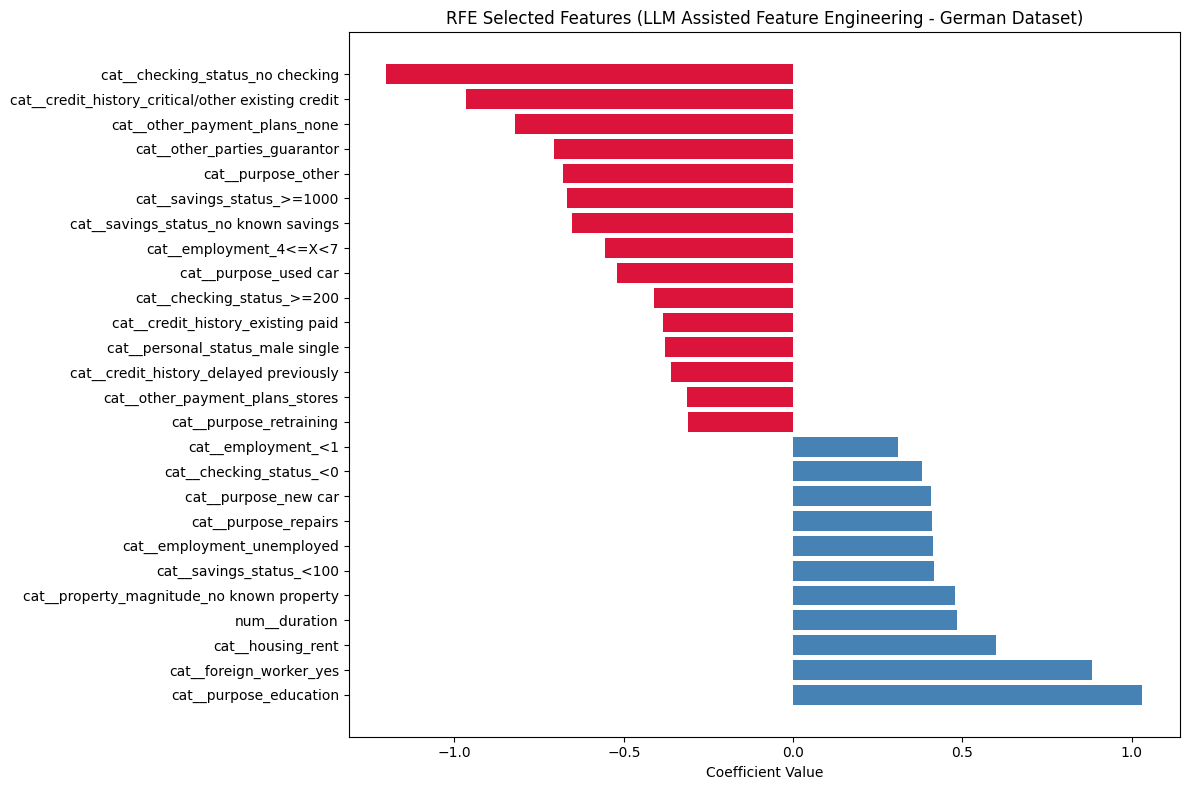

In [12]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#4682B4' if c > 0 else '#DC143C' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features (LLM Assisted Feature Engineering - German Dataset)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [13]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.001,
        max_iter=1000,
        solver='liblinear',
        penalty='l2',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "Logistic Regression", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[159  51]
 [ 26  64]]
classification_report:
               precision    recall  f1-score   support

           0       0.86      0.76      0.81       210
           1       0.56      0.71      0.62        90

    accuracy                           0.74       300
   macro avg       0.71      0.73      0.71       300
weighted avg       0.77      0.74      0.75       300

Model                   Logistic Regression
Method                                SMOTE
PR-AUC                              0.63044
ROC-AUC                             0.77455
Recall (Fraud)                     0.711111
Precision (Fraud)                  0.556522
F1-Score                            0.62439
True Positives (TP)                      64
False Negatives (FN)                     26
dtype: object


In [14]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
0                                       num__duration     0.074402
1                             cat__checking_status_<0     0.059164
13                           cat__savings_status_<100     0.046259
19          cat__property_magnitude_no known property     0.021130
23                                  cat__housing_rent     0.018835
7                              cat__purpose_education     0.012426
25                            cat__foreign_worker_yes     0.012035
8                                cat__purpose_new car     0.011814
5             cat__credit_history_no credits/all paid     0.009731
10                               cat__purpose_repairs     0.001137
9                                  cat__purpose_other     0.000721
11                            cat__purpose_retraining    -0.000383
6                     cat__purpose_domestic appliance    -0.001392
22                    cat__other_payment_plans_stores    -0.00

RF - CW

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=10,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "Random Forest","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[182  28]
 [ 43  47]]
classification_report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       210
           1       0.63      0.52      0.57        90

    accuracy                           0.76       300
   macro avg       0.72      0.69      0.70       300
weighted avg       0.75      0.76      0.76       300

Model                   Random Forest
Method                  Class Weights
PR-AUC                       0.623619
ROC-AUC                      0.792328
Recall (Fraud)               0.522222
Precision (Fraud)            0.626667
F1-Score                     0.569697
True Positives (TP)                47
False Negatives (FN)               43
dtype: object


In [16]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 14 out of 52 features.
num__loan_to_age_ratio              0.129906
num__credit_amount                  0.124882
num__est_monthly_income             0.120618
num__monthly_installment            0.115999
num__age                            0.096259
cat__checking_status_no checking    0.093876
num__duration                       0.081418
num__burden_per_dependent           0.039689
num__residence_since                0.037373
cat__savings_status_<100            0.034187
dtype: float64


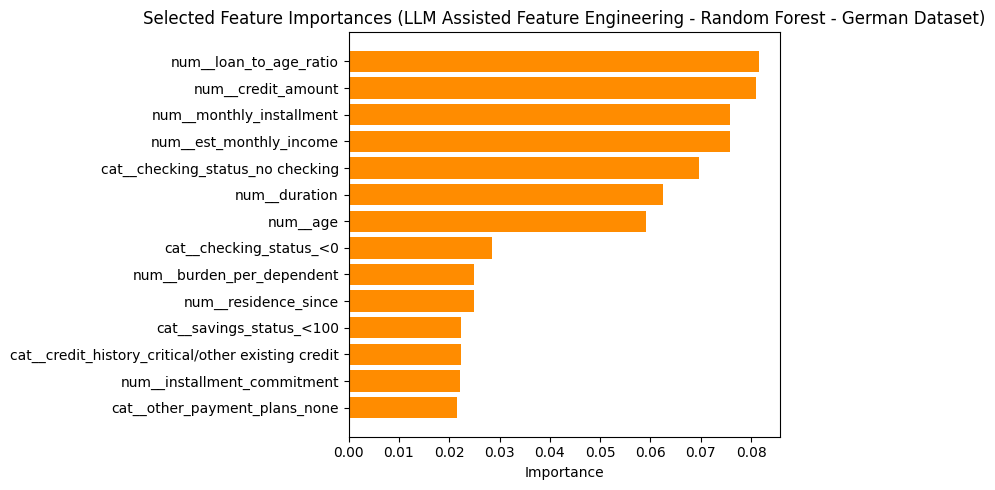

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#FF8C00'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Assisted Feature Engineering - Random Forest - German Dataset)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [18]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_features='log2',
        max_depth=20,
        criterion='entropy',
        n_jobs=-1,
        class_weight=None
    ))
]) 

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "Random Forest","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[181  29]
 [ 42  48]]
classification_report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84       210
           1       0.62      0.53      0.57        90

    accuracy                           0.76       300
   macro avg       0.72      0.70      0.71       300
weighted avg       0.76      0.76      0.76       300

Model                   Random Forest
Method                          SMOTE
PR-AUC                       0.561797
ROC-AUC                      0.773757
Recall (Fraud)               0.533333
Precision (Fraud)            0.623377
F1-Score                      0.57485
True Positives (TP)                48
False Negatives (FN)               42
dtype: object


In [19]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 18 out of 52 features.
cat__checking_status_no checking    0.112251
num__loan_to_age_ratio              0.095955
num__credit_amount                  0.087099
num__est_monthly_income             0.084393
num__monthly_installment            0.082434
num__duration                       0.079878
num__age                            0.074823
cat__checking_status_<0             0.066716
cat__savings_status_<100            0.044066
num__residence_since                0.042427
dtype: float64


XGB - CW

In [10]:
!pip install xgboost

In [11]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1] 
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGBoost","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[157  53]
 [ 33  57]]
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.75      0.79       210
           1       0.52      0.63      0.57        90

    accuracy                           0.71       300
   macro avg       0.67      0.69      0.68       300
weighted avg       0.73      0.71      0.72       300

Model                         XGBoost
Method                  Class Weights
PR-AUC                       0.548722
ROC-AUC                      0.762646
Recall (Fraud)               0.633333
Precision (Fraud)            0.518182
F1-Score                         0.57
True Positives (TP)                57
False Negatives (FN)               33
dtype: object


In [22]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 26 out of 52
cat__checking_status_no checking             0.127853
cat__other_payment_plans_none                0.060819
cat__credit_history_no credits/all paid      0.056343
cat__property_magnitude_real estate          0.055965
cat__savings_status_<100                     0.048944
cat__employment_<1                           0.048136
cat__property_magnitude_life insurance       0.044324
cat__property_magnitude_no known property    0.041439
cat__purpose_furniture/equipment             0.041207
cat__credit_history_delayed previously       0.040403
dtype: float32


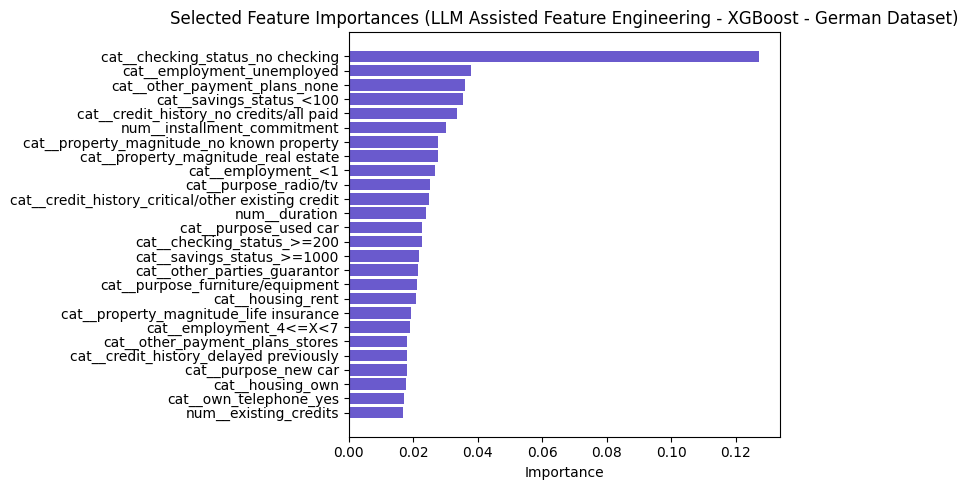

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#6A5ACD'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Assisted Feature Engineering - XGBoost - German Dataset)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [24]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[180  30]
 [ 44  46]]
classification_report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       210
           1       0.61      0.51      0.55        90

    accuracy                           0.75       300
   macro avg       0.70      0.68      0.69       300
weighted avg       0.74      0.75      0.75       300

Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.584894
ROC-AUC                 0.792169
Recall (Fraud)          0.511111
Precision (Fraud)       0.605263
F1-Score                0.554217
True Positives (TP)           46
False Negatives (FN)          44
dtype: object


In [25]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 26 out of 52
cat__checking_status_no checking                      0.179147
cat__checking_status_<0                               0.090976
cat__savings_status_<100                              0.077644
cat__property_magnitude_real estate                   0.051832
cat__purpose_education                                0.050206
cat__purpose_radio/tv                                 0.048087
cat__other_payment_plans_none                         0.044189
cat__credit_history_critical/other existing credit    0.043894
cat__other_parties_guarantor                          0.038185
cat__purpose_new car                                  0.037362
dtype: float32


In [ ]:
pd.Series(importances, index=X.columns).sort_values(ascending=False).plot.bar()

import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)  # Global beeswarm plot
shap.waterfall_plot(shap_values[0], X_test.iloc[0])  # Single prediction


In [26]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

                 Model         Method    PR-AUC   ROC-AUC  Recall (Fraud)  \
0  Logistic Regression  Class Weights  0.628357  0.774021        0.744444   
1  Logistic Regression          SMOTE  0.630440  0.774550        0.711111   
2        Random Forest  Class Weights  0.623619  0.792328        0.522222   
3        Random Forest          SMOTE  0.561797  0.773757        0.533333   
4              XGBoost  Class Weights  0.548722  0.762646        0.633333   
5              XGBoost          SMOTE  0.584894  0.792169        0.511111   

   Precision (Fraud)  F1-Score  True Positives (TP)  False Negatives (FN)  
0           0.531746  0.620370                   67                    23  
1           0.556522  0.624390                   64                    26  
2           0.626667  0.569697                   47                    43  
3           0.623377  0.574850                   48                    42  
4           0.518182  0.570000                   57                    33  
5   

Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

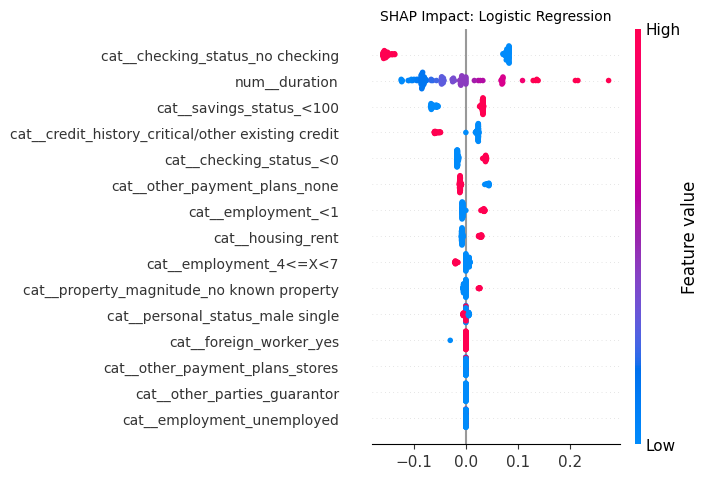

In [16]:
# --- LOGISTIC REGRESSION SHAP ---

import shap
import matplotlib.pyplot as plt
import numpy as np


model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

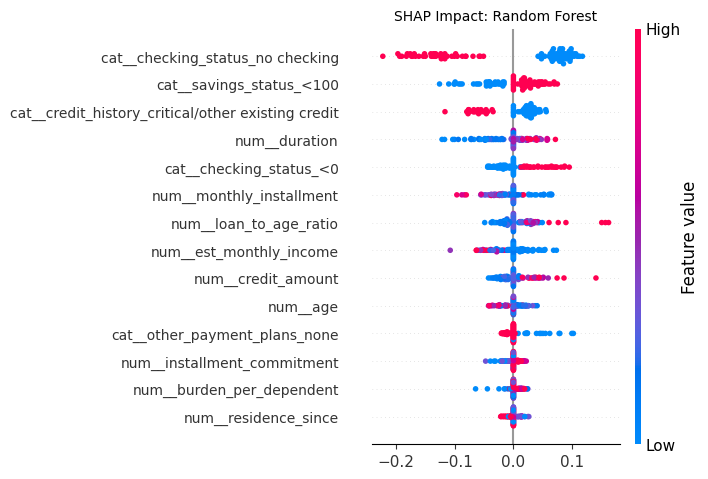

In [17]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

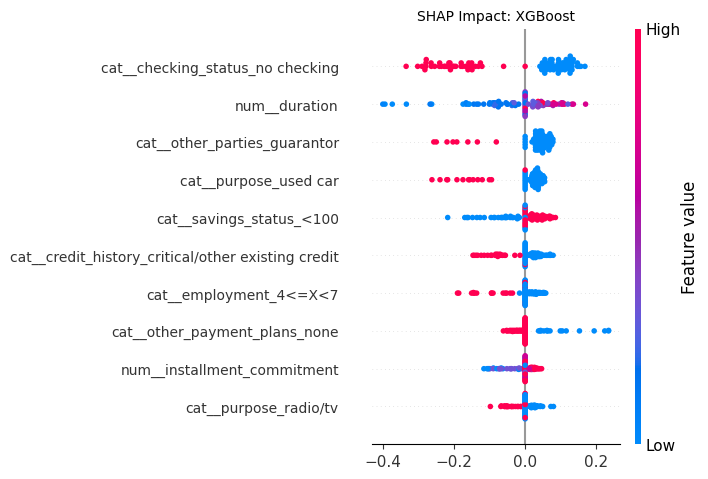

In [18]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()